# Powerflow Plotting Quick Test

This notebook is the Step 5 postprocessing workspace for DB-backed Step 4 power-flow results. It is meant to be a compact review notebook: first inspect one network/timestep spatially, then compare voltage, transformer loading, and line-loading stress summaries that scale from the current dummy grid to a larger grid population.

Use the Python kernel from `GridExpand/5.postprocessing/.venv` so the plotting and notebook dependencies are available.

Workflow:

- The setup cell resolves the repository root, imports the Step 5 plotting helpers, and selects one DB-backed power-flow run through `db_grid`, `run_name`, and `stage`.
- The network plot is for detailed spatial inspection of one timestep. Use it after the summary plots point to an interesting stage or timestep.
- The voltage and loading distribution plots are for population-level diagnosis. They are designed so the same notebook still works after the Munich batch contains many grids.

Current scope:

- `db_grid` selects the existing PLZ 94342 dummy test grid.
- `run_name = "baseline_static_full_powerflow"` selects the full Step 4 DB run.
- `stage = "post"` is used as the default detailed-inspection stage, while comparison plots explicitly load both `pre` and `post` where needed.


In [24]:
from pathlib import Path
import sys

# Resolve repository root even if notebook opens with a different working directory.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
root = next((p for p in candidates if (p / "GridExpand").exists()), None)
if root is None:
    raise RuntimeError("Could not find repository root containing 'GridExpand'.")

postprocessing_dir = root / "GridExpand/5.postprocessing"
for path in (root, postprocessing_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

root


PosixPath('/home/breveron/git/github/SurroGrid')

In [25]:
from IPython.display import display
import ipywidgets as widgets
import pandas as pd
import plotly.graph_objects as go

from powerflow.comparison_data import (
    powerflow_headline_summary_db,
    powerflow_percentile_profile_db,
)
from plotting.powerflow_asset_plots import plot_powerflow_headline_violins
from plotting.powerflow_heatmaps import (
    available_powerflow_results_db,
    db_powerflow_timestep_bounds,
    grid_loading_stress_summary,
    line_loading_distribution_db,
    plot_line_loading_ecdf,
    plot_powerflow_heatmap_db,
)
from plotting.powerflow_transformer import (
    plot_transformer_apparent_power_stage_comparison_matplotlib,
    plot_transformer_import_distributions_matplotlib,
    transformer_import_distribution_db,
)
from plotting.powerflow_voltage import (
    plot_voltage_deviation_histogram,
    voltage_deviation_summary_db,
)

run_name = "baseline_static_min_temperature_week_full_powerflow"
stage = "post"

available_results = available_powerflow_results_db(run_name=run_name, stages=("pre", "post"))
scenario_options = [
    (
        f"{int(row.scenario_id)}: {row.scenario_key}",
        int(row.scenario_id),
    )
    for row in available_results[["scenario_id", "scenario_key"]]
    .drop_duplicates()
    .sort_values(["scenario_id"])
    .itertuples(index=False)
]

scenario_dropdown = widgets.Dropdown(
    options=scenario_options,
    value=scenario_options[0][1],
    description="Scenario",
    layout=widgets.Layout(width="360px"),
)
scope_mode = widgets.Dropdown(
    options=[("All results", "all"), ("AGS", "ags"), ("PLZ", "plz")],
    value="all",
    description="Scope",
)
ags_dropdown = widgets.Dropdown(
    options=[("All", None)] + [(str(value).zfill(8), int(value)) for value in sorted(available_results["ags"].dropna().astype(int).unique())],
    value=None,
    description="AGS",
)
plz_dropdown = widgets.Dropdown(
    options=[("All", None)] + [(str(value), int(value)) for value in sorted(available_results["plz"].dropna().astype(int).unique())],
    value=None,
    description="PLZ",
)
stage_dropdown = widgets.Dropdown(
    options=[("Post", "post"), ("Pre", "pre")],
    value=stage,
    description="Stage",
)


def filtered_results():
    df = available_results.loc[
        available_results["scenario_id"].astype(int) == int(scenario_dropdown.value)
    ].copy()
    if scope_mode.value == "ags" and ags_dropdown.value is not None:
        df = df.loc[df["ags"].astype(int) == int(ags_dropdown.value)]
    if scope_mode.value == "plz" and plz_dropdown.value is not None:
        df = df.loc[df["plz"].astype(int) == int(plz_dropdown.value)]
    df = df.reset_index(drop=True)
    df.insert(0, "grid_row", df.index)
    return df


def current_scope_kwargs():
    selected_scenario_id = int(scenario_dropdown.value)
    mode = scope_mode.value
    if mode == "ags":
        return {"input_id": None, "scenario_id": selected_scenario_id, "ags": ags_dropdown.value, "plz": None, "kcid": None, "bcid": None}
    if mode == "plz":
        return {"input_id": None, "scenario_id": selected_scenario_id, "ags": None, "plz": plz_dropdown.value, "kcid": None, "bcid": None}
    return {"input_id": None, "scenario_id": selected_scenario_id, "ags": None, "plz": None, "kcid": None, "bcid": None}


controls = widgets.VBox([
    scenario_dropdown,
    widgets.HBox([scope_mode, ags_dropdown, plz_dropdown, stage_dropdown]),
])
display(controls)


In [26]:
grid_overview = filtered_results()[["grid_row", "grid", "scenario_id", "scenario_key", "run_name", "ags_label", "plz", "kcid", "bcid", "n_timesteps", "stages"]]
display(grid_overview)


,grid_row,grid,scenario_id,scenario_key,run_name,ags_label,plz,kcid,bcid,n_timesteps,stages
0,0,9162000-05_80337_1_-2.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,80337,1,-2,168,"[post, pre]"
1,1,9162000-06_80337_1_-1.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,80337,1,-1,168,"[post, pre]"
2,2,9162000-11_80339_2_2.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,80339,2,2,168,"[post, pre]"
3,3,9162000-12_80634_1_-2.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,80634,1,-2,168,"[post, pre]"
4,4,9162000-13_80634_1_-1.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,80634,1,-1,168,"[post, pre]"
...,...,...,...,...,...,...,...,...,...,...,...
284,284,9162000-293_81927_1_4.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,81927,1,4,168,"[post, pre]"
285,285,9162000-294_81927_1_5.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,81927,1,5,168,"[post, pre]"
286,286,9162000-295_81929_1_-1.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,81929,1,-1,168,"[post, pre]"
287,287,9162000-296_81929_1_1.h5,209,baseline_static_min_temperature_week,baseline_static_min_temperature_week_full_powe...,09162000,81929,1,1,168,"[post, pre]"


## Headline Summary-Only Metrics

This section reads the compact Step 4 `--summary-only` DB output. It compares one headline value each for transformer loading, cable loading, and voltage quality without requiring full timestep voltage/cable tables.


In [ ]:
headline_run_name = "baseline_static_pre_powerflow"
headline_stage = "pre"
headline_scope = current_scope_kwargs()

headline_summary = powerflow_headline_summary_db(
    run_name=headline_run_name,
    stage=headline_stage,
    ags=headline_scope["ags"],
    plz=headline_scope["plz"],
    kcid=headline_scope["kcid"],
    bcid=headline_scope["bcid"],
)

display(
    headline_summary[[
        "grid",
        "n_timesteps",
        "n_voltage_buses",
        "n_cables",
        "trafo_loading_p95_time_percent",
        "cable_loading_p95_asset_percent",
        "voltage_p05_load_bus_hour_pu",
    ]].style.format({
        "trafo_loading_p95_time_percent": "{:.2f}",
        "cable_loading_p95_asset_percent": "{:.2f}",
        "voltage_p05_load_bus_hour_pu": "{:.4f}",
    })
)

headline_profile = powerflow_percentile_profile_db(
    run_name=headline_run_name,
    stage=headline_stage,
    ags=headline_scope["ags"],
    plz=headline_scope["plz"],
    kcid=headline_scope["kcid"],
    bcid=headline_scope["bcid"],
)

HEADLINE_METRIC_CONFIG = {
    "Transformer": {
        "time_quantile": 1.0,
        "asset_quantile": 1.0,
    },
    "Cables": {
        "time_quantile": 1.0,
        "asset_quantile": 0.99,
    },
    "Voltage": {
        "time_quantile": 0.0,
        "asset_quantile": 0.01,
    },
}

display(
    plot_powerflow_headline_violins(
        headline_profile,
        metric_config=HEADLINE_METRIC_CONFIG,
        show=False,
    )
)


## Voltage Deviation Histogram

This mirrors the attached voltage-limit figure by comparing each grid's minimum and maximum voltage magnitude against the 0.9 p.u. and 1.1 p.u. limits.

How to read it:

- The blue histogram summarizes each grid's maximum upper-voltage value across all buses and timesteps in the selected stage.
- The green histogram summarizes each grid's minimum lower-voltage value across all buses and timesteps in the selected stage.
- The dashed vertical lines mark the 0.9 p.u. and 1.1 p.u. voltage thresholds.
- The annotations report the share of grids outside the voltage limits.

What to look for:

- A right-shifted blue tail beyond 1.1 p.u. indicates overvoltage risk, often relevant for feed-in-heavy scenarios.
- A left-shifted green tail below 0.9 p.u. indicates undervoltage risk, often relevant for high-load electrification scenarios.
- A narrow distribution close to 1.0 p.u. means most grids remain voltage-stable under the selected scenario.
- When the Munich batch is available, compare this plot between `pre` and `post` stages or between scenario runs to see whether electrification shifts the voltage-risk tail.


In [ ]:
scope = current_scope_kwargs()
voltage_summary = voltage_deviation_summary_db(
    input_id=scope["input_id"],
    run_name=run_name,
    scenario_id=scope["scenario_id"],
    stages=(stage_dropdown.value,),
    ags=scope["ags"],
    plz=scope["plz"],
    kcid=scope["kcid"],
    bcid=scope["bcid"],
)

display(plot_voltage_deviation_histogram(voltage_summary, lower_limit = 0.9, upper_limit = 1.01, show=False))

,grid,stage,n_timesteps,n_buses,min_vm_pu,max_vm_pu
0,09162000-80337_1_-2,post,168,130,0.9644,1.0000
1,09162000-80337_1_-1,post,168,110,0.9628,1.0000
2,09162000-80339_2_2,post,168,58,0.9769,1.0000
3,09162000-80634_2_1,post,168,24,0.9812,1.0000
4,09162000-80634_1_-2,post,168,28,0.9760,1.0000
5,09162000-80634_2_2,post,168,19,0.9708,1.0000
6,09162000-80634_1_-1,post,168,56,0.9544,1.0000
7,09162000-80634_2_3,post,168,66,0.9680,1.0000
8,09162000-80639_1_-6,post,168,108,0.9543,1.0000
9,09162000-80639_1_-4,post,168,38,0.9689,1.0000


In [ ]:
display(
    voltage_summary[[
        "grid",
        "stage",
        "n_timesteps",
        "n_buses",
        "min_vm_pu",
        "max_vm_pu",
    ]].style.format({
        "min_vm_pu": "{:.4f}",
        "max_vm_pu": "{:.4f}",
    })
)

## Transformer Import Distributions

This section uses the thesis plotting style from `thesis_plots.ipynb`: daily aggregation for the time-series panels, hourly load-duration curves, Gaussian-equivalent 68% and 96% percentile bands, and LDC normalization by the average per-grid maximum apparent load.

How to read it:

- Rows correspond to active power `P`, reactive power `|Q|`, and apparent power `|S|` transformer import.
- The left column shows daily aggregated seasonal behavior over the year.
- The right column shows load-duration curves, so high values near 0% duration are rare peaks and values toward 100% duration are persistent base levels.
- The dark line is the expected profile across grids. The darker and lighter bands show 68% and 96% percentile ranges.

What to look for:

- Active power `P` shows the dominant net import seasonality and peak-load behavior.
- Reactive power `|Q|` helps check whether reactive assumptions or compensation behavior materially affect transformer loading.
- Apparent power `|S|` is the transformer-loading quantity to watch for thermal capacity stress.
- Wide percentile bands mean grid-to-grid diversity is high; narrow bands mean the selected population behaves similarly.
- In the LDC panels, a steep left edge means short peak events dominate. A high curve over a broad duration range means sustained loading.

Use this full 3x2 plot when you want to understand the composition of transformer import. Use the next apparent-power-only pre/post plot when the question is specifically how electrification changes transformer loading shape.


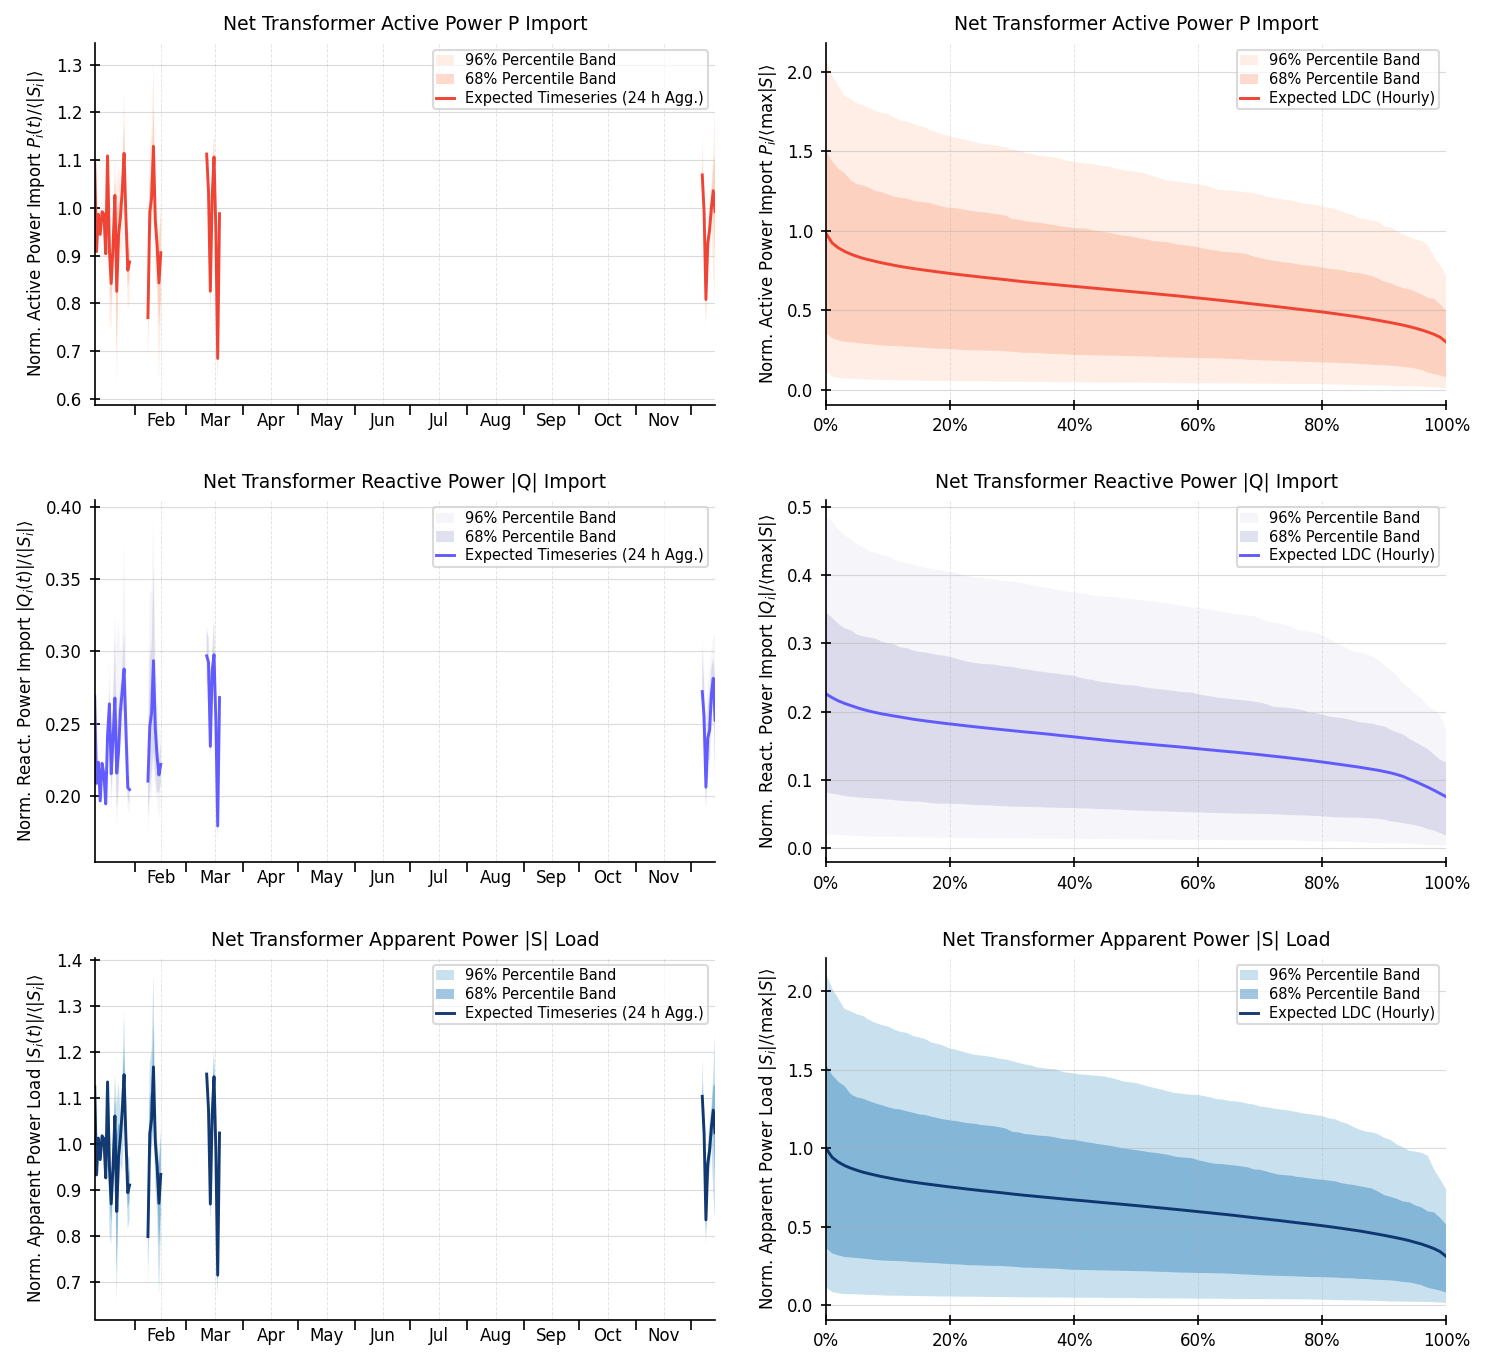

In [28]:
scope = current_scope_kwargs()
transformer_distribution = transformer_import_distribution_db(
    input_id=scope["input_id"],
    run_name=run_name,
    scenario_id=scope["scenario_id"],
    stage=stage_dropdown.value,
    ags=scope["ags"],
    plz=scope["plz"],
    kcid=scope["kcid"],
    bcid=scope["bcid"],
)

transformer_fig = plot_transformer_import_distributions_matplotlib(
    transformer_distribution,
    show=True,
)


## Apparent Transformer Load: Pre vs Post

This compares the daily aggregated apparent transformer load for the pre/status-quo power-flow stage on the left and the post/electrification stage on the right.

How to read it:

- Each panel shows the normalized apparent transformer load `|S|` over the year after daily aggregation.
- The dark line is the expected daily profile across the selected grid population.
- The darker and lighter bands show the 68% and 96% percentile ranges across grids, so wider bands mean stronger grid-to-grid diversity.
- The left panel is the electricity-only/status-quo power-flow case. The right panel is the post/electrification case.

What to look for:

- A higher or broader winter peak in the post panel indicates heat-pump or electrification-driven transformer stress.
- A flatter post profile can indicate that the new loads are spread more evenly over the year.
- Because this plot is normalized per stage, it is best for comparing seasonal shape and variability, not absolute MVA growth. Use transformer ratings or absolute-load plots if the question is capacity sizing.


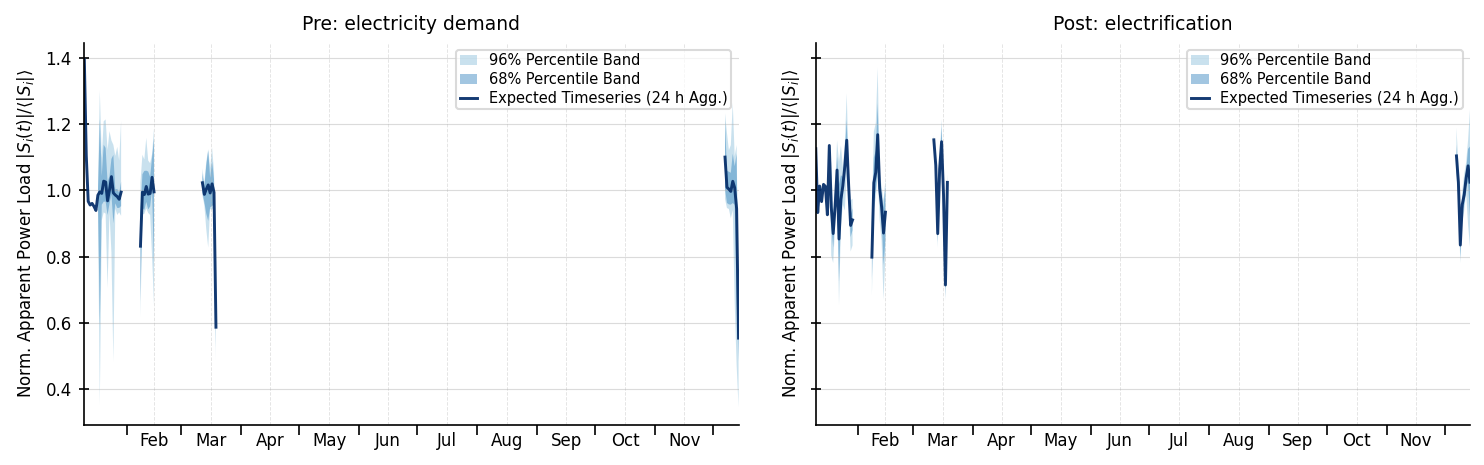

In [29]:
scope = current_scope_kwargs()
transformer_pre_distribution = transformer_import_distribution_db(
    input_id=scope["input_id"],
    run_name=run_name,
    scenario_id=scope["scenario_id"],
    stage="pre",
    ags=scope["ags"],
    plz=scope["plz"],
    kcid=scope["kcid"],
    bcid=scope["bcid"],
)
transformer_post_distribution = transformer_import_distribution_db(
    input_id=scope["input_id"],
    run_name=run_name,
    scenario_id=scope["scenario_id"],
    stage="post",
    ags=scope["ags"],
    plz=scope["plz"],
    kcid=scope["kcid"],
    bcid=scope["bcid"],
)

apparent_power_stage_fig = plot_transformer_apparent_power_stage_comparison_matplotlib(
    transformer_pre_distribution,
    transformer_post_distribution,
    show=True,
)


## Line Loading Stress Across Grids

This section summarizes line loading after the network has been solved. Run the cells in order: first build the line-loading data, then inspect the table and ECDF separately.

The table and ECDF use each line's maximum loading over all timesteps. Full timestep-series stress plots are intentionally skipped for now to keep the notebook lightweight.


In [30]:
scope = current_scope_kwargs()
line_loading = line_loading_distribution_db(
    input_id=scope["input_id"],
    run_name=run_name,
    scenario_id=scope["scenario_id"],
    stages=("pre", "post"),
    ags=scope["ags"],
    plz=scope["plz"],
    kcid=scope["kcid"],
    bcid=scope["bcid"],
)
line_stress = grid_loading_stress_summary(line_loading)


### Line Stress Table

Use this table to rank grids by robust stress metrics. `median_line_max_loading_percent` describes the typical line after each line's worst timestep, while `p95_line_max_loading_percent` captures the high-loading tail without depending on one single line.


In [31]:
# stress_table = line_stress[[
#     "grid",
#     "stage",
#     "n_lines",
#     "median_line_max_loading_percent",
#     "p95_line_max_loading_percent",
#     "max_line_loading_percent",
#     "share_lines_above_80_percent",
#     "share_lines_above_100_percent",
# ]].copy()

# display(
#     stress_table.style.format({
#         "median_line_max_loading_percent": "{:.2f}%",
#         "p95_line_max_loading_percent": "{:.2f}%",
#         "max_line_loading_percent": "{:.2f}%",
#         "share_lines_above_80_percent": "{:.1f}%",
#         "share_lines_above_100_percent": "{:.1f}%",
#     })
# )


### Line Maximum Loading ECDF

The ECDF shows the full distribution of line maximum loadings. Curves shifted to the right are more stressed, and the vertical lines mark 80% high-loading and 100% overload reference levels.


In [32]:
display(plot_line_loading_ecdf(line_loading, show=False))


## Network Plot

This single-grid heatmap is placed after the population stress plots so the grid can be selected from the grids that look most critical.

The dropdown is built from `line_stress` and sorted by `median_line_max_loading_percent` in descending order. Each option includes the grid, stage, median loading, p95 loading, and maximum loading. Selecting an option redraws the heatmap for that grid and stage.

Use this plot as a diagnostic lens after the summary plots identify an interesting grid or stress pattern.


In [33]:
if "line_stress" not in globals():
    scope = current_scope_kwargs()
    line_loading = line_loading_distribution_db(
        input_id=scope["input_id"],
        run_name=run_name,
        scenario_id=scope["scenario_id"],
        stages=("pre", "post"),
        ags=scope["ags"],
        plz=scope["plz"],
        kcid=scope["kcid"],
        bcid=scope["bcid"],
    )
    line_stress = grid_loading_stress_summary(line_loading)

network_candidates = (
    line_stress.sort_values("median_line_max_loading_percent", ascending=False)
    .reset_index(drop=True)
)
if network_candidates.empty:
    raise ValueError("No line stress rows available for network plot selection.")

network_options = [
    (
        f"{idx}: {row['grid']} | {row['scenario_key']} | {row['stage']} | "
        f"median {row['median_line_max_loading_percent']:.2f}% | "
        f"p95 {row['p95_line_max_loading_percent']:.2f}% | "
        f"max {row['max_line_loading_percent']:.2f}%",
        idx,
    )
    for idx, row in network_candidates.iterrows()
]
network_grid_dropdown = widgets.Dropdown(
    options=network_options,
    value=0,
    description="Grid",
    layout=widgets.Layout(width="900px"),
)


def selected_network_candidate():
    return network_candidates.iloc[int(network_grid_dropdown.value)]


def selected_network_grid_stage():
    row = selected_network_candidate()
    return str(row["grid"]), str(row["run_name"]), int(row["scenario_id"]), str(row["stage"])


heatmap_grid, heatmap_run_name, heatmap_scenario_id, heatmap_stage = selected_network_grid_stage()
bounds = db_powerflow_timestep_bounds(
    heatmap_grid,
    stage=heatmap_stage,
    run_name=heatmap_run_name,
    scenario_id=heatmap_scenario_id,
)

timestep_slider = widgets.IntSlider(
    value=bounds["min_timestep"],
    min=bounds["min_timestep"],
    max=bounds["max_timestep"],
    step=1,
    description="Timestep",
    continuous_update=False,
    layout=widgets.Layout(width="600px"),
)


def build_network_figure(timestep):
    grid, grid_run_name, grid_scenario_id, grid_stage = selected_network_grid_stage()
    return plot_powerflow_heatmap_db(
        input_id=grid,
        stage=grid_stage,
        timestep=timestep,
        on_map=False,
        map_style="light",
        cmap="Jet",
        climits_volt=(0.9, 1.1),
        climits_load=(0.0, 100.0),
        show_household_buses=False,
        show=False,
        run_name=grid_run_name,
        scenario_id=grid_scenario_id,
    )


initial_network_figure = build_network_figure(timestep_slider.value)
network_figure = go.FigureWidget(initial_network_figure)


def refresh_timestep_bounds(change=None):
    grid, grid_run_name, grid_scenario_id, grid_stage = selected_network_grid_stage()
    new_bounds = db_powerflow_timestep_bounds(
        grid,
        stage=grid_stage,
        run_name=grid_run_name,
        scenario_id=grid_scenario_id,
    )
    timestep_slider.min = new_bounds["min_timestep"]
    timestep_slider.max = new_bounds["max_timestep"]
    timestep_slider.value = new_bounds["min_timestep"]
    render_timestep()


def render_timestep(change=None):
    fig = build_network_figure(timestep_slider.value)
    with network_figure.batch_update():
        network_figure.data = []
        network_figure.add_traces(fig.data)
        network_figure.layout = fig.layout


timestep_slider.observe(render_timestep, names="value")
network_grid_dropdown.observe(refresh_timestep_bounds, names="value")
display(widgets.VBox([network_grid_dropdown, timestep_slider, network_figure]))
